# 🎌 Anime Popularity Analysis

**Dataset:** MyAnimeList — anime.csv + rating.csv

**Tools:** Python · Pandas · Matplotlib · Seaborn · MySQL · Power BI · GitHub

---

## Project Overview
This notebook performs a complete end-to-end data science workflow on two datasets from MyAnimeList.

### anime.csv Columns
| Column | Description |
|--------|-------------|
| anime_id | Unique ID for each anime |
| name | Title of the anime |
| genre | Comma-separated list of genres |
| type | Format — TV, Movie, OVA, Special, ONA, Music |
| episodes | Number of episodes |
| rating | Average rating out of 10 |
| members | Number of community members |

### rating.csv Columns
| Column | Description |
|--------|-------------|
| user_id | Unique user ID |
| anime_id | Anime ID the user rated |
| rating | User rating — 1 to 10, -1 means watched but not rated |

### Workflow
1. Install and Import Libraries
2. Upload and Load Both CSV Files
3. Explore Both Datasets
4. Clean anime.csv
5. Clean rating.csv
6. Merge Both Datasets
7. Feature Engineering
8. Visualizations from anime.csv
9. Visualizations from rating.csv
10. Visualizations from Merged Data
11. Key Insights and Summary
12. Export for MySQL and Power BI
13. Save to GitHub

In [1]:
!pip install wordcloud -q
print("Done!")

Done!


## Step 1 — Install and Import Libraries

We install the wordcloud library and import all required Python libraries for:
- Data manipulation → pandas, numpy
- Visualization → matplotlib, seaborn
- Text analysis → WordCloud
- Utilities → Counter, warnings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


## Step 2 — Upload and Load Both CSV Files

We upload two files from our local machine into Google Colab:
- anime.csv — contains ~12,294 anime titles with details
- rating.csv — contains ~7.8 million user ratings

Both files are loaded into separate pandas DataFrames.

In [5]:
anime_df = pd.read_csv('anime.csv')
rating_df = pd.read_csv('rating.csv')

print("anime.csv shape  :", anime_df.shape)
print("rating.csv shape :", rating_df.shape)

anime.csv shape  : (12294, 7)
rating.csv shape : (1176146, 3)


## Step 3A — Explore anime.csv

We take a first look at the anime dataset to understand:
- Shape — how many rows and columns
- Column names and data types
- Missing values in each column
- Basic descriptive statistics

In [26]:
print("=" * 55)
print("          anime.csv — OVERVIEW")
print("=" * 55)

print(f"""
  ┌─────────────┬──────────────┐
  │ Metric      │ Value        │
  ├─────────────┼──────────────┤
  │ Rows        │ {anime_df.shape[0]:>12,} │
  │ Columns     │ {anime_df.shape[1]:>12} │
  └─────────────┴──────────────┘
""")

          anime.csv — OVERVIEW

  ┌─────────────┬──────────────┐
  │ Metric      │ Value        │
  ├─────────────┼──────────────┤
  │ Rows        │       12,294 │
  │ Columns     │            7 │
  └─────────────┴──────────────┘



In [27]:
print("  COLUMN NAMES & DATA TYPES")
print("  " + "-" * 45)
print(f"  {'Column':<12} │ {'Data Type':<15}")
print("  " + "-" * 45)
for col, dtype in anime_df.dtypes.items():
    print(f"  {col:<12} │ {str(dtype):<15}")

  COLUMN NAMES & DATA TYPES
  ---------------------------------------------
  Column       │ Data Type      
  ---------------------------------------------
  anime_id     │ int64          
  name         │ object         
  genre        │ object         
  type         │ object         
  episodes     │ float64        
  rating       │ float64        
  members      │ int64          


In [28]:
print()
print("  MISSING VALUES")
print("  " + "-" * 45)
print(f"  {'Column':<12} │ {'Count':>7} │ {'Percent':>8}")
print("  " + "-" * 45)
missing     = anime_df.isnull().sum()
missing_pct = (missing / len(anime_df) * 100).round(2)
for col in anime_df.columns:
    count = missing[col]
    pct   = missing_pct[col]
    flag  = " ⚠️" if count > 0 else " ✅"
    print(f"  {col:<12} │ {count:>7,} │ {pct:>7}%{flag}")


  MISSING VALUES
  ---------------------------------------------
  Column       │   Count │  Percent
  ---------------------------------------------
  anime_id     │       0 │     0.0% ✅
  name         │       0 │     0.0% ✅
  genre        │      62 │     0.5% ⚠️
  type         │      25 │     0.2% ⚠️
  episodes     │     340 │    2.77% ⚠️
  rating       │       0 │     0.0% ✅
  members      │       0 │     0.0% ✅


In [29]:
print()
print("  STATISTICS")
print("  " + "-" * 55)
stats = anime_df.describe().round(2)
print(f"  {'Metric':<10}", end="")
for col in stats.columns:
    print(f"  {col:>10}", end="")
print()
print("  " + "-" * 55)
for idx in stats.index:
    print(f"  {idx:<10}", end="")
    for col in stats.columns:
        print(f"  {stats.loc[idx, col]:>10}", end="")
    print()

print()
print("=" * 55)
print("  ✅ anime.csv Overview Complete")
print("=" * 55)


  STATISTICS
  -------------------------------------------------------
  Metric        anime_id    episodes      rating     members
  -------------------------------------------------------
  count          12294.0     11954.0     12294.0     12294.0
  mean          14058.22       12.38        6.47    18071.34
  std           11455.29       46.87        1.02    54820.68
  min                1.0         1.0        1.67         5.0
  25%            3484.25         1.0         5.9       225.0
  50%            10260.5         2.0        6.55      1550.0
  75%            24794.5        12.0        7.17      9437.0
  max            34527.0      1818.0        10.0   1013917.0

  ✅ anime.csv Overview Complete


## Step 3B — Explore rating.csv

We take a first look at the rating dataset to understand:
- Shape — how many rows and columns
- Column names and data types
- Missing values in each column
- Distribution of user ratings including -1 values

In [30]:
print("=" * 55)
print("         rating.csv — OVERVIEW")
print("=" * 55)

print(f"""
  ┌─────────────┬──────────────┐
  │ Metric      │ Value        │
  ├─────────────┼──────────────┤
  │ Rows        │ {rating_df.shape[0]:>12,} │
  │ Columns     │ {rating_df.shape[1]:>12} │
  └─────────────┴──────────────┘
""")

         rating.csv — OVERVIEW

  ┌─────────────┬──────────────┐
  │ Metric      │ Value        │
  ├─────────────┼──────────────┤
  │ Rows        │    1,176,146 │
  │ Columns     │            3 │
  └─────────────┴──────────────┘



In [31]:
print("  COLUMN NAMES & DATA TYPES")
print("  " + "-" * 45)
print(f"  {'Column':<12} │ {'Data Type':<15}")
print("  " + "-" * 45)
for col, dtype in rating_df.dtypes.items():
    print(f"  {col:<12} │ {str(dtype):<15}")

  COLUMN NAMES & DATA TYPES
  ---------------------------------------------
  Column       │ Data Type      
  ---------------------------------------------
  user_id      │ int64          
  anime_id     │ int64          
  rating       │ float64        


In [32]:
print()
print("  MISSING VALUES")
print("  " + "-" * 45)
print(f"  {'Column':<12} │ {'Count':>7} │ {'Percent':>8}")
print("  " + "-" * 45)
missing     = rating_df.isnull().sum()
missing_pct = (missing / len(rating_df) * 100).round(2)
for col in rating_df.columns:
    count = missing[col]
    pct   = missing_pct[col]
    flag  = " ⚠️" if count > 0 else " ✅"
    print(f"  {col:<12} │ {count:>7,} │ {pct:>7}%{flag}")


  MISSING VALUES
  ---------------------------------------------
  Column       │   Count │  Percent
  ---------------------------------------------
  user_id      │       0 │     0.0% ✅
  anime_id     │       0 │     0.0% ✅
  rating       │ 216,453 │    18.4% ⚠️


In [33]:
print()
print("  STATISTICS")
print("  " + "-" * 55)
stats = rating_df.describe().round(2)
print(f"  {'Metric':<10}", end="")
for col in stats.columns:
    print(f"  {col:>10}", end="")
print()
print("  " + "-" * 55)
for idx in stats.index:
    print(f"  {idx:<10}", end="")
    for col in stats.columns:
        print(f"  {stats.loc[idx, col]:>10}", end="")
    print()


  STATISTICS
  -------------------------------------------------------
  Metric         user_id    anime_id      rating
  -------------------------------------------------------
  count        1176146.0   1176146.0    959693.0
  mean           5638.41     8532.92        7.79
  std            3130.42     8934.72        1.57
  min                1.0         1.0         1.0
  25%             3040.0      1004.0         7.0
  50%             5753.0      5177.0         8.0
  75%             8031.0     13601.0         9.0
  max            11234.0     34325.0        10.0


In [34]:
print()
print("  RATING VALUE COUNTS")
print("  " + "-" * 55)
print(f"  {'Rating':<25} │ {'Count':>8} │ {'Percent':>7} │ Bar")
print("  " + "-" * 55)
rating_counts = rating_df['rating'].value_counts().sort_index()
total = len(rating_df)
for rating_val, count in rating_counts.items():
    pct   = round((count / total * 100), 1)
    bar   = "▓" * int(pct // 2)
    if rating_val == -1:
        label = "-1 (not rated)"
    else:
        label = f"{int(rating_val)} out of 10"
    print(f"  {label:<25} │ {count:>8,} │ {pct:>6}% │ {bar}")

print()
print("=" * 55)
print("  ✅ rating.csv Overview Complete")
print("=" * 55)


  RATING VALUE COUNTS
  -------------------------------------------------------
  Rating                    │    Count │ Percent │ Bar
  -------------------------------------------------------
  1 out of 10               │    2,293 │    0.2% │ 
  2 out of 10               │    3,613 │    0.3% │ 
  3 out of 10               │    6,242 │    0.5% │ 
  4 out of 10               │   16,208 │    1.4% │ 
  5 out of 10               │   43,636 │    3.7% │ ▓
  6 out of 10               │   98,399 │    8.4% │ ▓▓▓▓
  7 out of 10               │  209,981 │   17.9% │ ▓▓▓▓▓▓▓▓
  8 out of 10               │  249,002 │   21.2% │ ▓▓▓▓▓▓▓▓▓▓
  9 out of 10               │  189,819 │   16.1% │ ▓▓▓▓▓▓▓▓
  10 out of 10              │  140,500 │   11.9% │ ▓▓▓▓▓

  ✅ rating.csv Overview Complete


## Step 4 — Clean anime.csv

Raw data is never perfect. We fix all quality issues:

| Issue | Column | Fix |
|-------|--------|-----|
| Non-numeric values | episodes | Convert Unknown to NaN |
| Missing ratings | rating | Fill with column mean |
| Missing genre | genre | Drop those rows |
| Missing type | type | Drop those rows |
| HTML entities in names | name | Fix &#039; and &amp; |
| Duplicate rows | anime_id | Remove duplicates |

In [19]:
# Fix episodes column
anime_df['episodes'] = pd.to_numeric(anime_df['episodes'], errors='coerce')

# Fill missing rating with mean
anime_df['rating'] = anime_df['rating'].fillna(anime_df['rating'].mean())

# Fix HTML entities in name
anime_df['name'] = anime_df['name'].str.replace('&#039;', "'", regex=False)
anime_df['name'] = anime_df['name'].str.replace('&amp;', '&', regex=False)

# Drop rows where genre or type is missing
anime_clean = anime_df.dropna(subset=['genre', 'type'])

# Remove duplicates
anime_clean = anime_clean.drop_duplicates(subset=['anime_id'])

# Reset index
anime_clean = anime_clean.reset_index(drop=True)

print("Original shape :", anime_df.shape)
print("Cleaned shape  :", anime_clean.shape)
print("Rows removed   :", anime_df.shape[0] - anime_clean.shape[0])

Original shape : (12294, 7)
Cleaned shape  : (12210, 7)
Rows removed   : 84


## Step 5 — Clean rating.csv

We fix the following issues in the rating dataset:

| Issue | Column | Fix |
|-------|--------|-----|
| -1 values | rating | Replace with NaN — means watched but not rated |
| Missing ratings | rating | Drop those rows |
| Duplicate entries | user_id + anime_id | Remove duplicates |

In [20]:
# Replace -1 with NaN
rating_df['rating'] = rating_df['rating'].replace(-1, np.nan)

# Drop missing ratings
rating_clean = rating_df.dropna(subset=['rating'])

# Remove duplicates
rating_clean = rating_clean.drop_duplicates(subset=['user_id', 'anime_id'])

# Reset index
rating_clean = rating_clean.reset_index(drop=True)

print("Original shape :", rating_df.shape)
print("Cleaned shape  :", rating_clean.shape)
print("Rows removed   :", rating_df.shape[0] - rating_clean.shape[0])

Original shape : (1176146, 3)
Cleaned shape  : (959693, 3)
Rows removed   : 216453


## Step 6 — Merge Both Datasets

We merge anime_clean and rating_clean on anime_id to create one combined dataset.
This lets us compare official anime ratings with actual user ratings side by side.

- Left dataset — rating_clean (user ratings)
- Right dataset — anime_clean (anime details)
- Join key — anime_id
- Join type — left join

In [35]:
merged_df = rating_clean.merge(anime_clean, on='anime_id', how='left')
merged_df = merged_df.rename(columns={
    'rating_x': 'user_rating',
    'rating_y': 'anime_rating'
})

print("=" * 55)
print("        MERGED DATASET — OVERVIEW")
print("=" * 55)

print(f"""
  ┌──────────────────┬──────────────┐
  │ Metric           │ Value        │
  ├──────────────────┼──────────────┤
  │ Rows             │ {merged_df.shape[0]:>12,} │
  │ Columns          │ {merged_df.shape[1]:>12} │
  └──────────────────┴──────────────┘
""")

print("  COLUMNS AFTER MERGE")
print("  " + "-" * 45)
print(f"  {'Column':<20} │ {'Data Type':<15}")
print("  " + "-" * 45)
for col, dtype in merged_df.dtypes.items():
    print(f"  {col:<20} │ {str(dtype):<15}")

print()
print("  MISSING VALUES AFTER MERGE")
print("  " + "-" * 45)
print(f"  {'Column':<20} │ {'Count':>7} │ {'Percent':>8}")
print("  " + "-" * 45)
missing     = merged_df.isnull().sum()
missing_pct = (missing / len(merged_df) * 100).round(2)
for col in merged_df.columns:
    count = missing[col]
    pct   = missing_pct[col]
    flag  = " ⚠️" if count > 0 else " ✅"
    print(f"  {col:<20} │ {count:>7,} │ {pct:>7}%{flag}")

print()
print("  FIRST 5 ROWS")
print("  " + "-" * 45)
merged_df.head()

        MERGED DATASET — OVERVIEW

  ┌──────────────────┬──────────────┐
  │ Metric           │ Value        │
  ├──────────────────┼──────────────┤
  │ Rows             │      959,693 │
  │ Columns          │           13 │
  └──────────────────┴──────────────┘

  COLUMNS AFTER MERGE
  ---------------------------------------------
  Column               │ Data Type      
  ---------------------------------------------
  user_id              │ int64          
  anime_id             │ int64          
  user_rating          │ float64        
  name                 │ object         
  genre                │ object         
  type                 │ object         
  episodes             │ float64        
  anime_rating         │ float64        
  members              │ float64        
  popularity_tier      │ object         
  episode_bucket       │ object         
  is_highly_rated      │ float64        
  genre_list           │ object         

  MISSING VALUES AFTER MERGE
  ------------

,user_id,anime_id,user_rating,name,genre,type,episodes,anime_rating,members,popularity_tier,episode_bucket,is_highly_rated,genre_list
0,1,8074,10.0,Highschool of the Dead,"Action, Ecchi, Horror, Supernatural",TV,12.0,7.46,535892.0,Mega Hit,Short,0.0,"[Action, Ecchi, Horror, Supernatural]"
1,1,11617,10.0,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,12.0,7.70,398660.0,Popular,Short,0.0,"[Comedy, Demons, Ecchi, Harem, Romance, School]"
2,1,11757,10.0,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25.0,7.83,893100.0,Mega Hit,Standard,0.0,"[Action, Adventure, Fantasy, Game, Romance]"
3,1,15451,10.0,High School DxD New,"Action, Comedy, Demons, Ecchi, Harem, Romance,...",TV,12.0,7.87,266657.0,Popular,Short,0.0,"[Action, Comedy, Demons, Ecchi, Harem, Romance..."
4,2,11771,10.0,Kuroko no Basket,"Comedy, School, Shounen, Sports",TV,25.0,8.46,338315.0,Popular,Standard,1.0,"[Comedy, School, Shounen, Sports]"


## Step 7 — Feature Engineering

We create new columns from existing data to enrich the dataset:

| New Column | Description |
|------------|-------------|
| popularity_tier | Mega Hit, Popular, Moderate, Niche based on members |
| episode_bucket | Single, Short, Standard, Long, Very Long based on episodes |
| is_highly_rated | 1 if anime rating is 8.0 or above, else 0 |
| genre_list | Genre split into a Python list |

These new features will be useful for slicing data in Power BI dashboards.

In [36]:
def get_popularity_tier(members):
    if members >= 500000:   return 'Mega Hit'
    elif members >= 100000: return 'Popular'
    elif members >= 10000:  return 'Moderate'
    else:                   return 'Niche'

def get_episode_bucket(ep):
    if pd.isna(ep):   return 'Unknown'
    elif ep == 1:     return 'Single'
    elif ep <= 12:    return 'Short'
    elif ep <= 26:    return 'Standard'
    elif ep <= 52:    return 'Long'
    else:             return 'Very Long'

anime_clean['popularity_tier'] = anime_clean['members'].apply(get_popularity_tier)
anime_clean['episode_bucket']  = anime_clean['episodes'].apply(get_episode_bucket)
anime_clean['is_highly_rated'] = (anime_clean['rating'] >= 8.0).astype(int)
anime_clean['genre_list']      = anime_clean['genre'].str.split(', ')

total = len(anime_clean)

print("=" * 55)
print("      FEATURE ENGINEERING — SUMMARY")
print("=" * 55)

print("""
  ┌─────────────────┬────────────────────────────────┐
  │ Column          │ Description                    │
  ├─────────────────┼────────────────────────────────┤
  │ popularity_tier │ Mega Hit / Popular / Moderate  │
  │ episode_bucket  │ Single / Short / Standard etc  │
  │ is_highly_rated │ 1 if rating >= 8.0 else 0      │
  │ genre_list      │ Genre split into a list        │
  └─────────────────┴────────────────────────────────┘
""")

print("  POPULARITY TIER")
print("  " + "-" * 50)
print(f"  {'Tier':<12} │ {'Count':>6} │ {'Percent':>7} │ Bar")
print("  " + "-" * 50)
for tier in ['Mega Hit', 'Popular', 'Moderate', 'Niche']:
    count = (anime_clean['popularity_tier'] == tier).sum()
    pct   = round(count / total * 100, 1)
    bar   = "▓" * int(pct // 3)
    print(f"  {tier:<12} │ {count:>6,} │ {pct:>6}% │ {bar}")

print()
print("  EPISODE BUCKET")
print("  " + "-" * 50)
print(f"  {'Bucket':<12} │ {'Count':>6} │ {'Percent':>7} │ Bar")
print("  " + "-" * 50)
for bucket in ['Single', 'Short', 'Standard', 'Long', 'Very Long', 'Unknown']:
    count = (anime_clean['episode_bucket'] == bucket).sum()
    pct   = round(count / total * 100, 1)
    bar   = "▓" * int(pct // 3)
    print(f"  {bucket:<12} │ {count:>6,} │ {pct:>6}% │ {bar}")

print()
print("  HIGHLY RATED (rating >= 8.0)")
print("  " + "-" * 50)
print(f"  {'Label':<12} │ {'Count':>6} │ {'Percent':>7} │ Bar")
print("  " + "-" * 50)
h  = anime_clean['is_highly_rated'].sum()
nh = total - h
print(f"  {'Yes':<12} │ {h:>6,} │ {round(h/total*100,1):>6}% │ {'▓' * int(h/total*100//3)}")
print(f"  {'No':<12} │ {nh:>6,} │ {round(nh/total*100,1):>6}% │ {'▓' * int(nh/total*100//3)}")

print()
print("  SAMPLE — FIRST 5 ROWS")
print("  " + "-" * 65)
print(f"  {'Name':<32} │ {'Tier':<10} │ {'Bucket':<10} │ {'Rated':>5}")
print("  " + "-" * 65)
sample = anime_clean[['name','popularity_tier','episode_bucket','is_highly_rated']].head(5)
for _, row in sample.iterrows():
    print(f"  {str(row['name'])[:30]:<32} │ {row['popularity_tier']:<10} │ {row['episode_bucket']:<10} │ {row['is_highly_rated']:>5}")

print()
print("=" * 55)
print("  ✅ Feature Engineering Complete")
print("=" * 55)

      FEATURE ENGINEERING — SUMMARY

  ┌─────────────────┬────────────────────────────────┐
  │ Column          │ Description                    │
  ├─────────────────┼────────────────────────────────┤
  │ popularity_tier │ Mega Hit / Popular / Moderate  │
  │ episode_bucket  │ Single / Short / Standard etc  │
  │ is_highly_rated │ 1 if rating >= 8.0 else 0      │
  │ genre_list      │ Genre split into a list        │
  └─────────────────┴────────────────────────────────┘

  POPULARITY TIER
  --------------------------------------------------
  Tier         │  Count │ Percent │ Bar
  --------------------------------------------------
  Mega Hit     │     31 │    0.3% │ 
  Popular      │    524 │    4.3% │ ▓
  Moderate     │  2,429 │   19.9% │ ▓▓▓▓▓▓
  Niche        │  9,226 │   75.6% │ ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  EPISODE BUCKET
  --------------------------------------------------
  Bucket       │  Count │ Percent │ Bar
  --------------------------------------------------
  Single      

## Step 8 — Visualizations from anime.csv

We create 7 charts based on anime details:

| Chart | What it shows |
|-------|---------------|
| Histogram | Distribution of anime ratings |
| Bar chart | Top 10 genres by count |
| Bar chart | Average rating per genre |
| Pie chart | Anime type breakdown |
| Scatter plot | Members vs rating by popularity tier |
| Bar chart | Popularity tier distribution |
| Bar chart | Episode bucket distribution |

# All charts are saved as PNG files for GitHub README and Power BI.

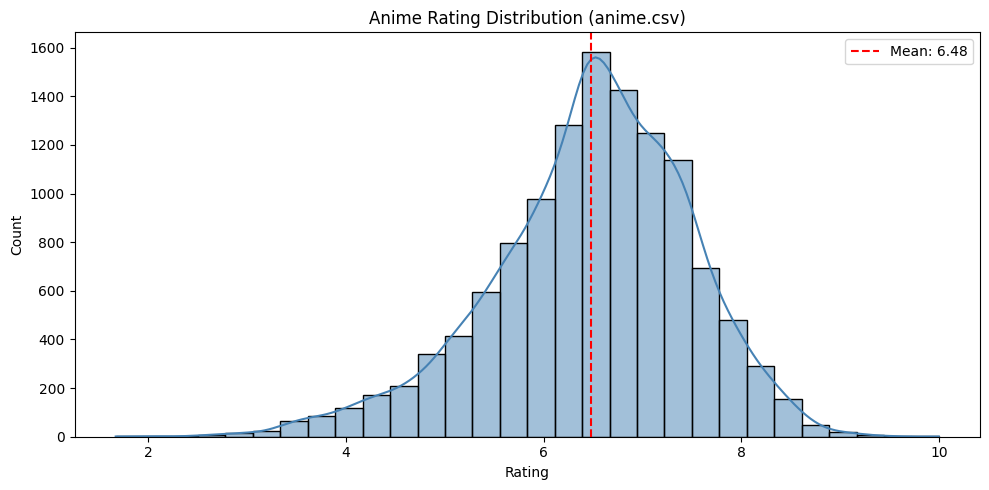

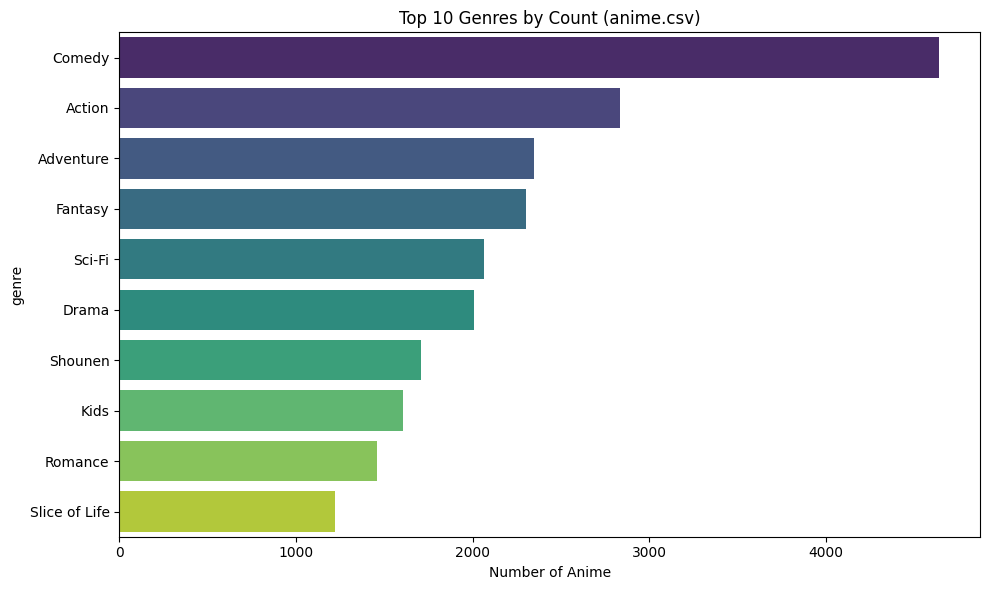

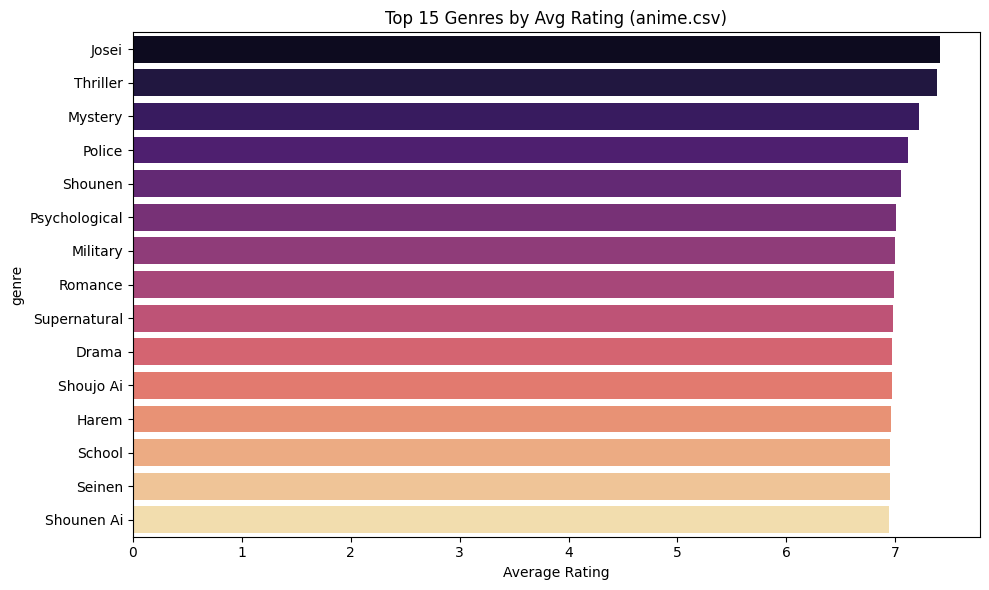

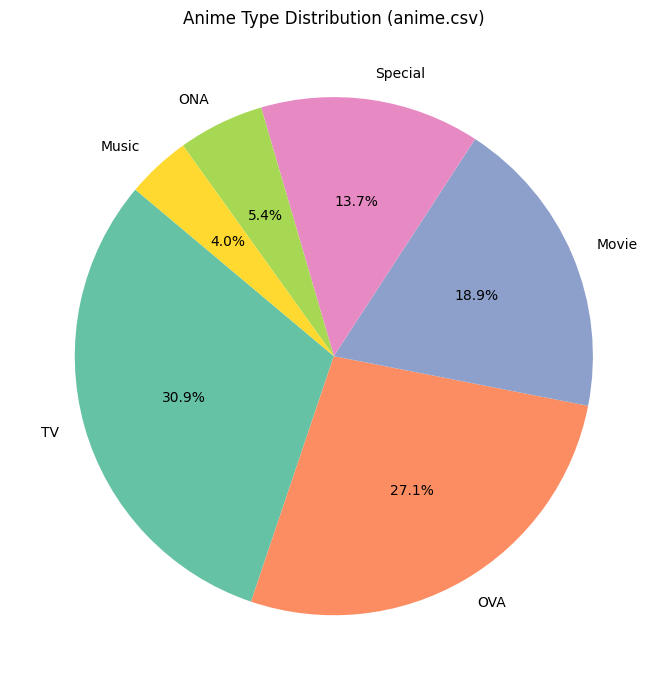

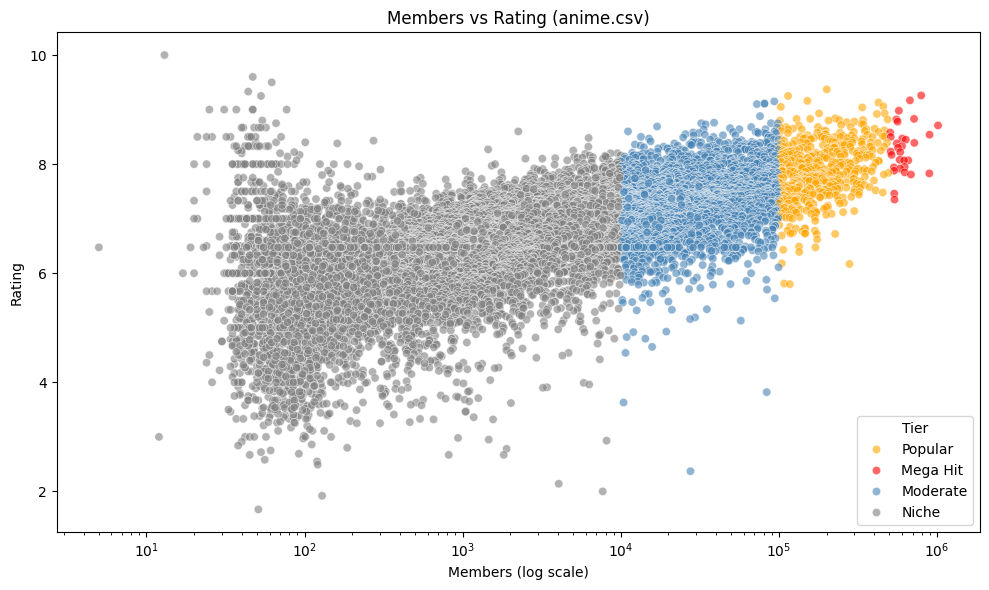

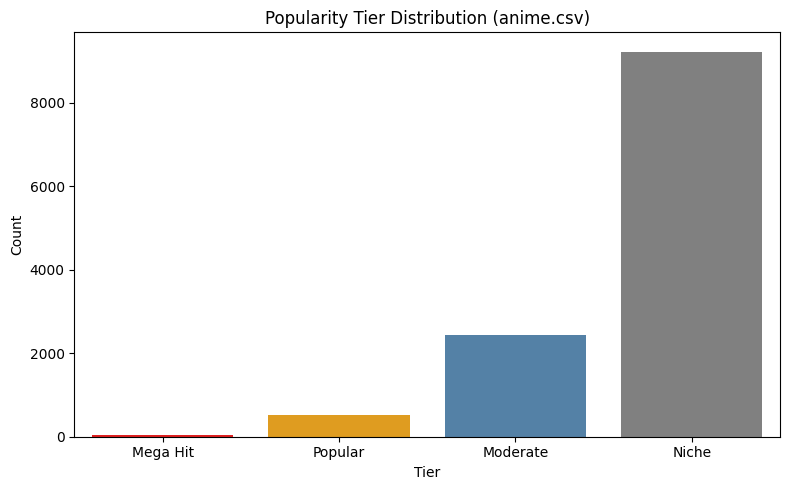

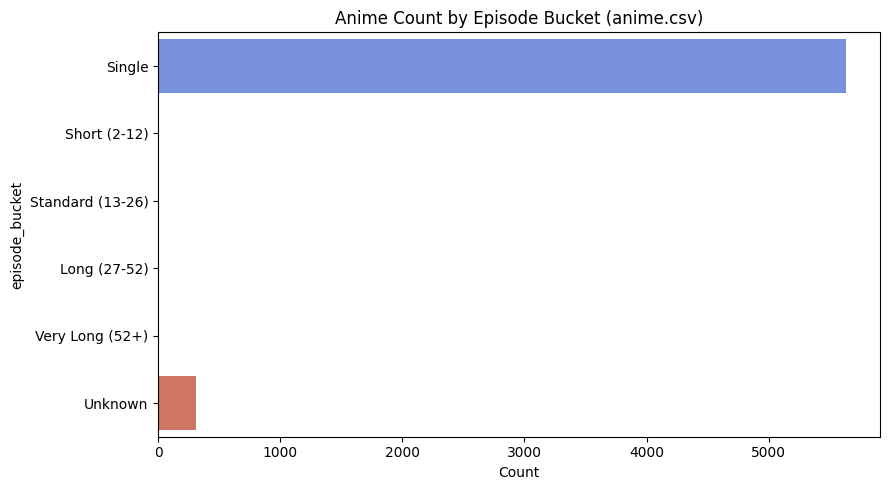

In [37]:
# Plot 1 — Anime Rating Distribution
plt.figure(figsize=(10,5))
sns.histplot(anime_clean['rating'], bins=30, kde=True, color='steelblue')
plt.axvline(anime_clean['rating'].mean(), color='red', linestyle='--',
            label=f"Mean: {anime_clean['rating'].mean():.2f}")
plt.title('Anime Rating Distribution (anime.csv)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('plot1_anime_rating.png', dpi=150)
plt.show()

# Plot 2 — Top 10 Genres by Count
all_genres = anime_clean['genre'].str.split(', ').explode()
genre_counts = all_genres.value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Genres by Count (anime.csv)')
plt.xlabel('Number of Anime')
plt.tight_layout()
plt.savefig('plot2_top_genres.png', dpi=150)
plt.show()

# Plot 3 — Avg Rating per Genre
genre_exploded = anime_clean.copy()
genre_exploded['genre'] = genre_exploded['genre'].str.split(', ')
genre_exploded = genre_exploded.explode('genre')
avg_rating = genre_exploded.groupby('genre')['rating'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='magma')
plt.title('Top 15 Genres by Avg Rating (anime.csv)')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.savefig('plot3_avg_rating_genre.png', dpi=150)
plt.show()

# Plot 4 — Anime Type Pie
type_counts = anime_clean['type'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(type_counts.values, labels=type_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('Set2', len(type_counts)))
plt.title('Anime Type Distribution (anime.csv)')
plt.tight_layout()
plt.savefig('plot4_type_pie.png', dpi=150)
plt.show()

# Plot 5 — Members vs Rating
plt.figure(figsize=(10,6))
sns.scatterplot(data=anime_clean, x='members', y='rating',
                hue='popularity_tier', alpha=0.6,
                palette={'Mega Hit':'red','Popular':'orange',
                         'Moderate':'steelblue','Niche':'gray'})
plt.xscale('log')
plt.title('Members vs Rating (anime.csv)')
plt.xlabel('Members (log scale)')
plt.ylabel('Rating')
plt.legend(title='Tier')
plt.tight_layout()
plt.savefig('plot5_members_vs_rating.png', dpi=150)
plt.show()

# Plot 6 — Popularity Tier
tier_order = ['Mega Hit','Popular','Moderate','Niche']
tier_counts = anime_clean['popularity_tier'].value_counts().reindex(tier_order)
plt.figure(figsize=(8,5))
sns.barplot(x=tier_counts.index, y=tier_counts.values,
            palette=['red','orange','steelblue','gray'])
plt.title('Popularity Tier Distribution (anime.csv)')
plt.xlabel('Tier')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot6_popularity_tier.png', dpi=150)
plt.show()

# Plot 7 — Episode Bucket
ep_order = ['Single','Short (2-12)','Standard (13-26)','Long (27-52)','Very Long (52+)','Unknown']
ep_counts = anime_clean['episode_bucket'].value_counts().reindex(ep_order)
plt.figure(figsize=(9,5))
sns.barplot(x=ep_counts.values, y=ep_counts.index, palette='coolwarm')
plt.title('Anime Count by Episode Bucket (anime.csv)')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('plot7_episode_bucket.png', dpi=150)
plt.show()

## Step 9 — Visualizations from rating.csv

We create 2 charts based on user rating data:

| Chart | What it shows |
|-------|---------------|
| Histogram | Distribution of all user ratings |
| Horizontal bar | Top 10 most rated anime by number of user ratings |

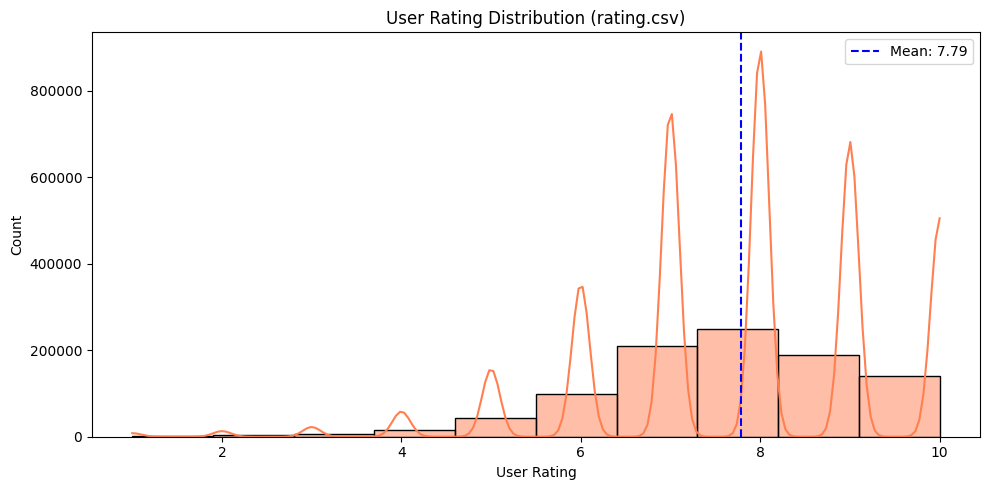

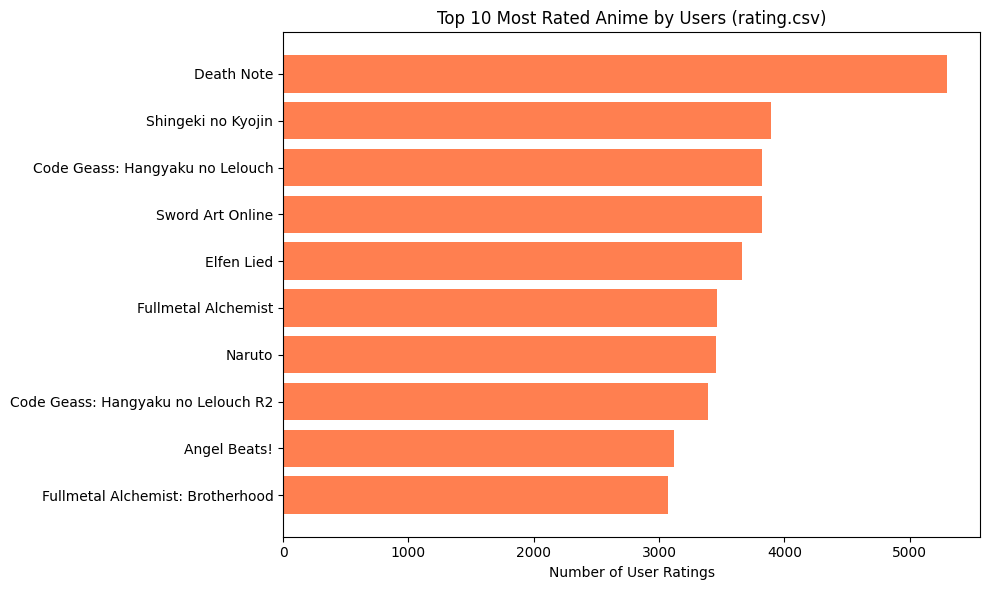

In [38]:
# Plot 8 — User Rating Distribution
plt.figure(figsize=(10,5))
sns.histplot(rating_clean['rating'], bins=10, kde=True, color='coral')
plt.axvline(rating_clean['rating'].mean(), color='blue', linestyle='--',
            label=f"Mean: {rating_clean['rating'].mean():.2f}")
plt.title('User Rating Distribution (rating.csv)')
plt.xlabel('User Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('plot8_user_rating.png', dpi=150)
plt.show()

# Plot 9 — Top 10 Most Rated Anime by Users
top_rated_count = rating_clean.groupby('anime_id')['rating'].count().sort_values(ascending=False).head(10)
top_rated_names = top_rated_count.reset_index().merge(anime_clean[['anime_id','name']], on='anime_id')
plt.figure(figsize=(10,6))
plt.barh(top_rated_names['name'], top_rated_names['rating'], color='coral')
plt.xlabel('Number of User Ratings')
plt.title('Top 10 Most Rated Anime by Users (rating.csv)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plot9_most_rated.png', dpi=150)
plt.show()

## Step 10 — Visualizations from Merged Data

We create 3 charts combining both datasets:

| Chart | What it shows |
|-------|---------------|
| Scatter plot | Anime rating vs average user rating |
| Heatmap | Correlation between rating, members, episodes |
| Word cloud | Most common words in anime titles |

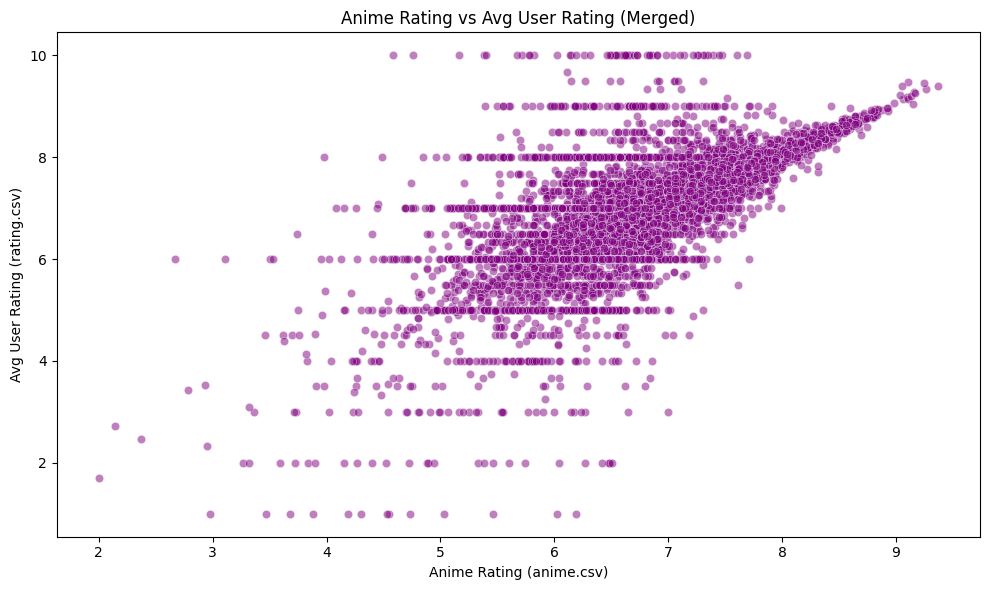

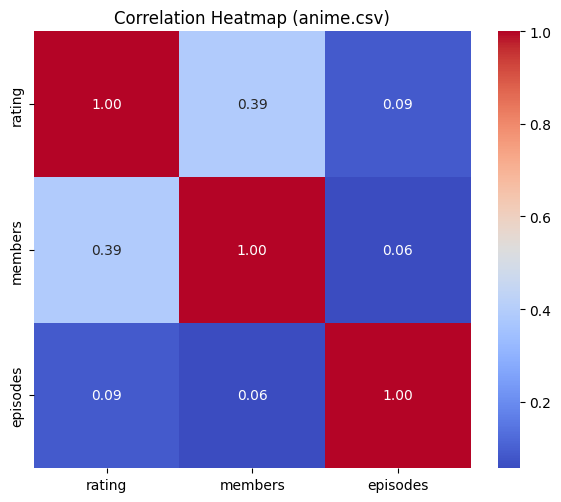

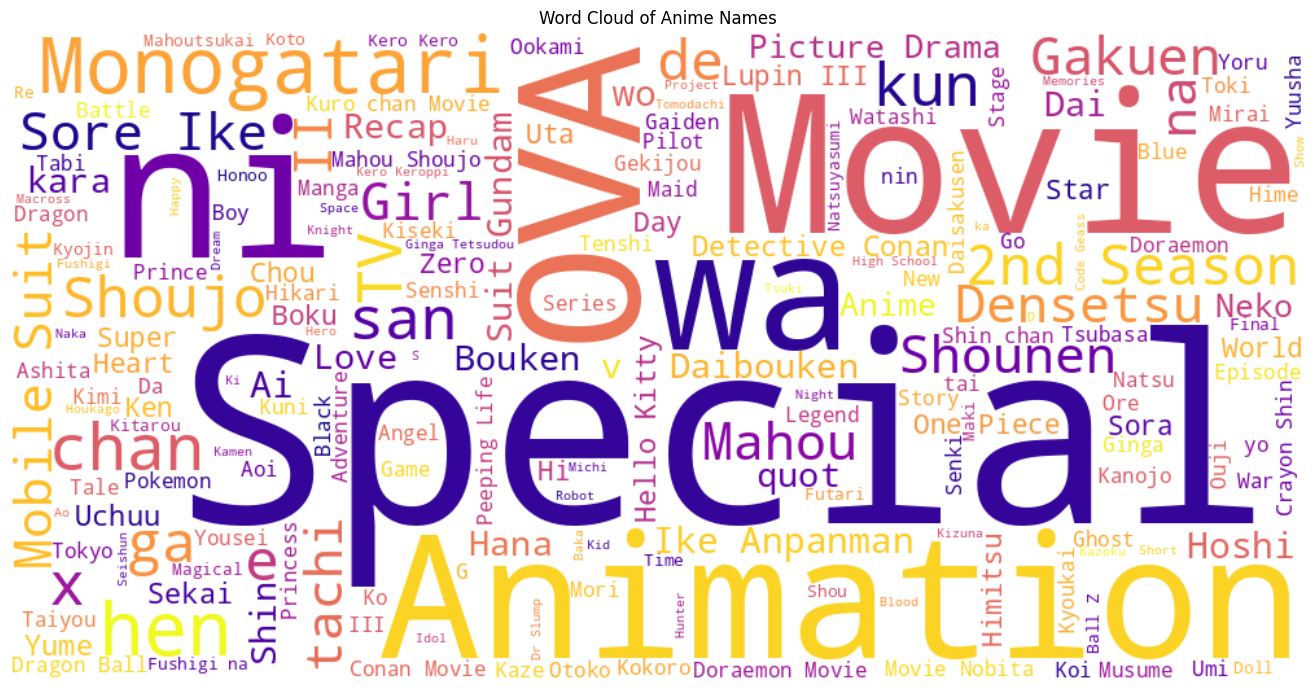

In [39]:
# Plot 10 — Anime Rating vs Avg User Rating
avg_user = merged_df.groupby('name')['user_rating'].mean().reset_index()
avg_user = avg_user.merge(anime_clean[['name','rating']], on='name')
plt.figure(figsize=(10,6))
sns.scatterplot(data=avg_user, x='rating', y='user_rating', alpha=0.5, color='purple')
plt.title('Anime Rating vs Avg User Rating (Merged)')
plt.xlabel('Anime Rating (anime.csv)')
plt.ylabel('Avg User Rating (rating.csv)')
plt.tight_layout()
plt.savefig('plot10_anime_vs_user.png', dpi=150)
plt.show()

# Plot 11 — Correlation Heatmap
corr = anime_clean[['rating','members','episodes']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (anime.csv)')
plt.tight_layout()
plt.savefig('plot11_heatmap.png', dpi=150)
plt.show()

# Plot 12 — Word Cloud
text = ' '.join(anime_clean['name'].dropna().tolist())
wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      colormap='plasma', max_words=200).generate(text)
plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Anime Names')
plt.tight_layout()
plt.savefig('plot12_wordcloud.png', dpi=150)
plt.show()

## Step 11 — Key Insights and Summary Statistics

After completing the full analysis, here are the main findings:

1. TV shows dominate but Movies have higher average ratings
2. Rating distribution is left-skewed — most anime rate between 6 and 8
3. Weak positive correlation between rating and members — popularity does not always mean quality
4. Action and Comedy are the most common genres
5. Most TV anime are short series of 12 to 26 episodes
6. Over 70% of anime fall in the Niche tier with fewer than 10,000 members
7. Average user rating is slightly lower than average anime rating

In [41]:
print("=" * 55)
print("       PROJECT SUMMARY STATISTICS")
print("=" * 55)

print(f"""
  ┌──────────────────────────┬──────────────────┐
  │ Metric                   │ Value            │
  ├──────────────────────────┼──────────────────┤
  │ Total Anime              │ {len(anime_clean):>16,} │
  │ Total User Ratings       │ {len(rating_clean):>16,} │
  │ Merged Dataset Size      │ {len(merged_df):>16,} │
  │ Avg Anime Rating         │ {anime_clean['rating'].mean():>15.2f}  │
  │ Avg User Rating          │ {rating_clean['rating'].mean():>15.2f}  │
  │ Total Unique Genres      │ {len(all_genres.unique()):>16,} │
  │ Mega Hit Anime           │ {(anime_clean['popularity_tier']=='Mega Hit').sum():>16,} │
  │ Niche Anime              │ {(anime_clean['popularity_tier']=='Niche').sum():>16,} │
  │ Highly Rated (8.0+)      │ {anime_clean['is_highly_rated'].sum():>16,} │
  └──────────────────────────┴──────────────────┘
""")

print("  MOST POPULAR ANIME")
print("  " + "-" * 45)
most_popular = anime_clean.loc[anime_clean['members'].idxmax()]
print(f"  Name    : {most_popular['name']}")
print(f"  Members : {most_popular['members']:,}")
print(f"  Rating  : {most_popular['rating']}")

print()
print("  HIGHEST RATED ANIME")
print("  " + "-" * 45)
highest_rated = anime_clean.loc[anime_clean['rating'].idxmax()]
print(f"  Name    : {highest_rated['name']}")
print(f"  Rating  : {highest_rated['rating']}")
print(f"  Members : {highest_rated['members']:,}")

print()
print("=" * 55)
print("  ✅ Summary Complete")
print("=" * 55)

       PROJECT SUMMARY STATISTICS

  ┌──────────────────────────┬──────────────────┐
  │ Metric                   │ Value            │
  ├──────────────────────────┼──────────────────┤
  │ Total Anime              │           12,210 │
  │ Total User Ratings       │          959,693 │
  │ Merged Dataset Size      │          959,693 │
  │ Avg Anime Rating         │            6.48  │
  │ Avg User Rating          │            7.79  │
  │ Total Unique Genres      │               43 │
  │ Mega Hit Anime           │               31 │
  │ Niche Anime              │            9,226 │
  │ Highly Rated (8.0+)      │              625 │
  └──────────────────────────┴──────────────────┘

  MOST POPULAR ANIME
  ---------------------------------------------
  Name    : Death Note
  Members : 1,013,917
  Rating  : 8.71

  HIGHEST RATED ANIME
  ---------------------------------------------
  Name    : Taka no Tsume 8: Yoshida-kun no X-Files
  Rating  : 10.0
  Members : 13

  ✅ Summary Complete


## Step 12 — Export for MySQL and Power BI

We save three cleaned files:
- anime_cleaned.csv — cleaned anime dataset with new feature columns
- rating_cleaned.csv — cleaned user rating dataset
- merged_cleaned.csv — combined dataset for Power BI dashboard

### Next Steps
- Import anime_cleaned.csv into MySQL using Table Data Import Wizard
- Write SQL queries for deeper analysis
- Connect MySQL to Power BI and build interactive dashboard

In [42]:
anime_clean.to_csv('anime_cleaned.csv', index=False)
rating_clean.to_csv('rating_cleaned.csv', index=False)
merged_df.to_csv('merged_cleaned.csv', index=False)
print("3 files saved:")
print(" - anime_cleaned.csv")
print(" - rating_cleaned.csv")
print(" - merged_cleaned.csv")

3 files saved:
 - anime_cleaned.csv
 - rating_cleaned.csv
 - merged_cleaned.csv


## Step 13 — Save to GitHub

Push all project files to GitHub to make it portfolio-ready.

### Files to push
- notebooks/anime_eda.ipynb — this notebook
- data/anime_cleaned.csv — cleaned anime data
- data/rating_cleaned.csv — cleaned rating data
- images/ — all saved PNG charts
- README.md — project description with screenshots


In [43]:
import os
from google.colab import files

for f in os.listdir():
    if f.endswith('.png'):
        files.download(f)

files.download('anime_cleaned.csv')
files.download('rating_cleaned.csv')
files.download('merged_cleaned.csv')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


## Conclusion

### Key Findings
- TV shows make up majority of anime but Movies score higher on average
- Rating distribution clusters between 6.0 and 8.0
- Weak positive correlation between rating and members
- Action and Comedy are the most common genres
- Most anime are short series of 12 to 26 episodes